<a href="https://colab.research.google.com/github/chandrahzzz/EDA-COURSE/blob/main/1D%2C2D%2CNDipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c("e1071","ggplot2","dplyr","reshape2","GGally"), repos = "http://cran.us.r-project.org")
library(e1071)
library(ggplot2)
library(dplyr)
library(reshape2)
library(GGally)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘proxy’, ‘plyr’, ‘ggstats’



Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
df <- read.csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/catholic.csv")
str(df)
summary(df)

'data.frame':	7430 obs. of  14 variables:
 $ rownames: int  1 2 3 4 5 6 7 8 9 10 ...
 $ id      : int  124902 124915 124916 124932 124944 124947 124966 124968 124972 124974 ...
 $ read12  : num  61.4 58.3 59.3 49.6 57.6 ...
 $ math12  : num  49.8 59.8 50.4 45 54.3 ...
 $ female  : int  0 0 1 1 1 1 1 0 0 0 ...
 $ asian   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispan  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ black   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ motheduc: num  14 14 14 12 12 12 14 14 14 14 ...
 $ fatheduc: num  12 14 11 14 12 11 14 14 14 12 ...
 $ lfaminc : num  10.3 10.3 10.3 10.3 10.7 ...
 $ hsgrad  : int  1 1 1 1 1 1 1 1 1 1 ...
 $ cathhs  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ parcath : int  1 1 1 1 1 1 1 1 1 1 ...


    rownames          id              read12          math12     
 Min.   :   1   Min.   : 124902   Min.   :29.15   Min.   :29.50  
 1st Qu.:1858   1st Qu.:2424049   1st Qu.:44.52   1st Qu.:45.02  
 Median :3716   Median :4592442   Median :53.08   Median :52.53  
 Mean   :3716   Mean   :4589838   Mean   :51.77   Mean   :52.13  
 3rd Qu.:5573   3rd Qu.:7241106   3rd Qu.:59.47   3rd Qu.:59.86  
 Max.   :7430   Max.   :7979086   Max.   :68.09   Max.   :71.37  
                                                                 
     female           asian             hispan           black        
 Min.   :0.0000   Min.   :0.00000   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:0.0000   1st Qu.:0.00000   1st Qu.:0.0000   1st Qu.:0.00000  
 Median :1.0000   Median :0.00000   Median :0.0000   Median :0.00000  
 Mean   :0.5174   Mean   :0.05168   Mean   :0.1035   Mean   :0.07066  
 3rd Qu.:1.0000   3rd Qu.:0.00000   3rd Qu.:0.0000   3rd Qu.:0.00000  
 Max.   :1.0000   Max.   :1.00000   Max.   :1.

In [3]:
x <- df$read12

stats <- c(
  Mean     = mean(x, na.rm = TRUE),
  Median   = median(x, na.rm = TRUE),
  Minimum  = min(x, na.rm = TRUE),
  Maximum  = max(x, na.rm = TRUE),
  Range    = max(x, na.rm = TRUE) - min(x, na.rm = TRUE),
  Variance = var(x, na.rm = TRUE),
  SD       = sd(x, na.rm = TRUE),
  IQR      = IQR(x, na.rm = TRUE),
  Skewness = skewness(x, na.rm = TRUE),
  Kurtosis = kurtosis(x, na.rm = TRUE)
)

stats_df <- data.frame(Statistic = names(stats), Value = round(stats, 4))
print(stats_df)


   0    1 
6978  452 

         0          1 
0.93916555 0.06083445 


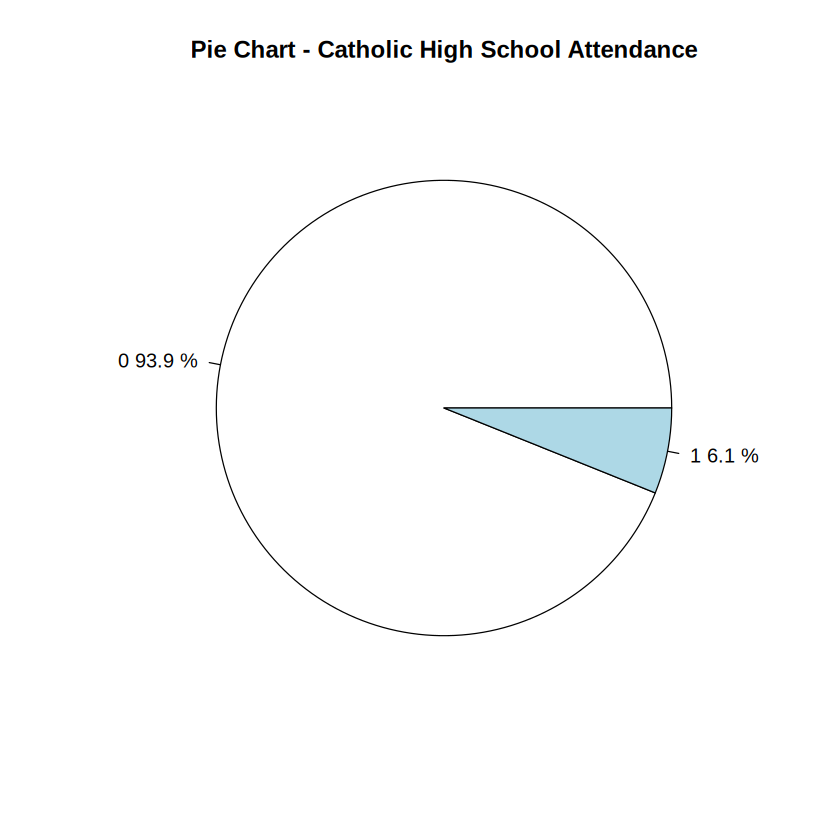

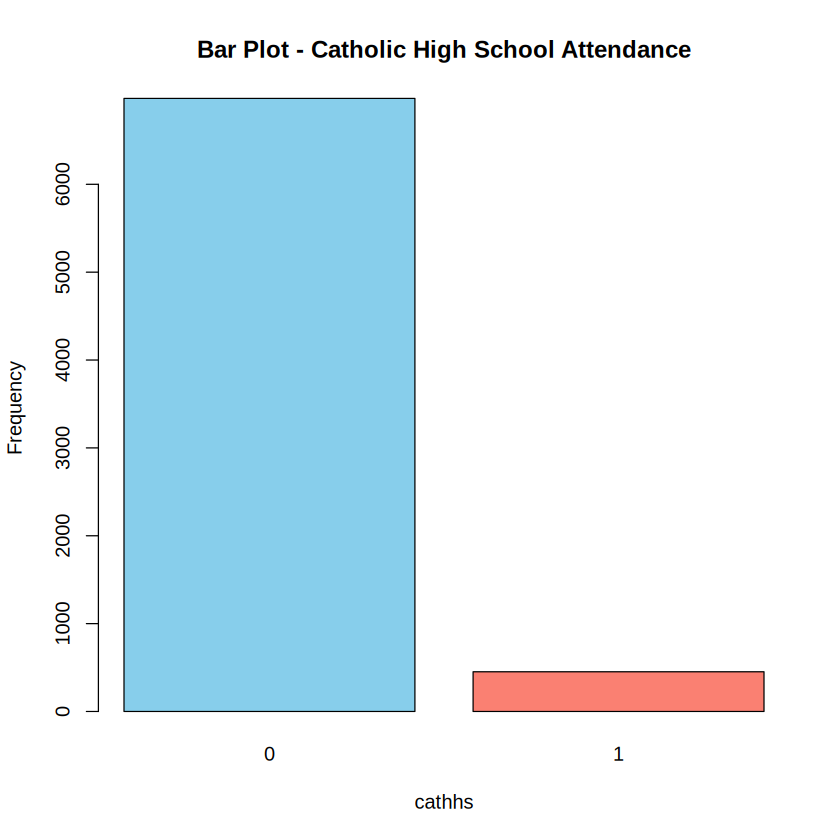

In [4]:

freq_table <- table(df$cathhs)
rel_freq_table <- prop.table(freq_table)

print(freq_table)
print(rel_freq_table)

pie(freq_table, labels = paste(names(freq_table), round(100*rel_freq_table,1), "%"),
    main = "Pie Chart - Catholic High School Attendance")

barplot(freq_table, main = "Bar Plot - Catholic High School Attendance",
        xlab = "cathhs", ylab = "Frequency", col = c("skyblue","salmon"))

bins
(20,25] (25,30] (30,35] (35,40] (40,45] (45,50] (50,55] (55,60] (60,65] (65,70] 
      0      21     357     684     888     989    1320    1472    1303     396 


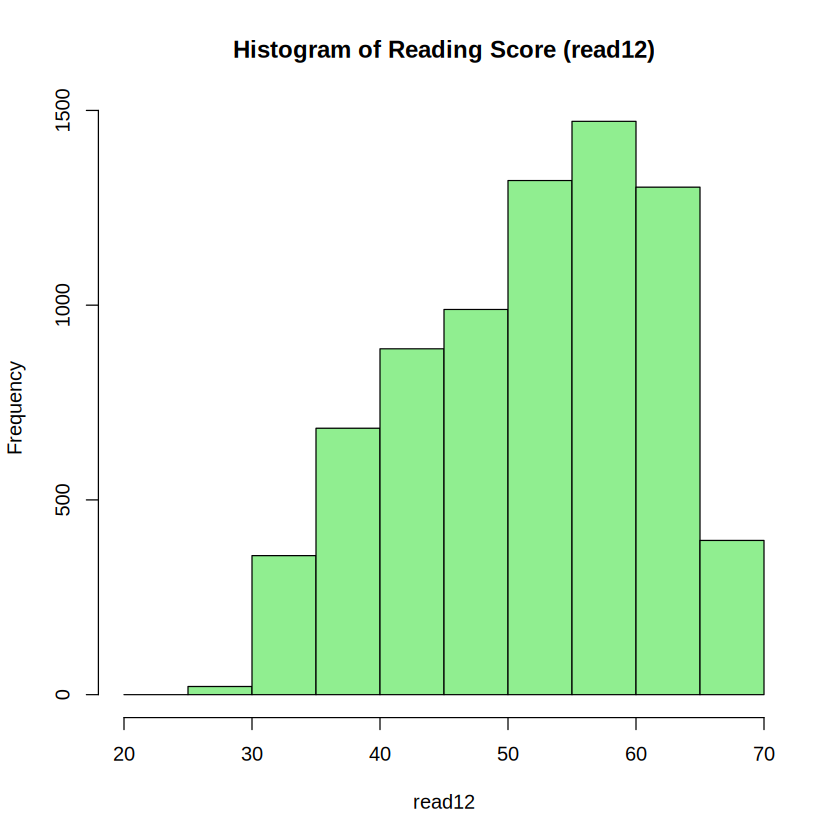

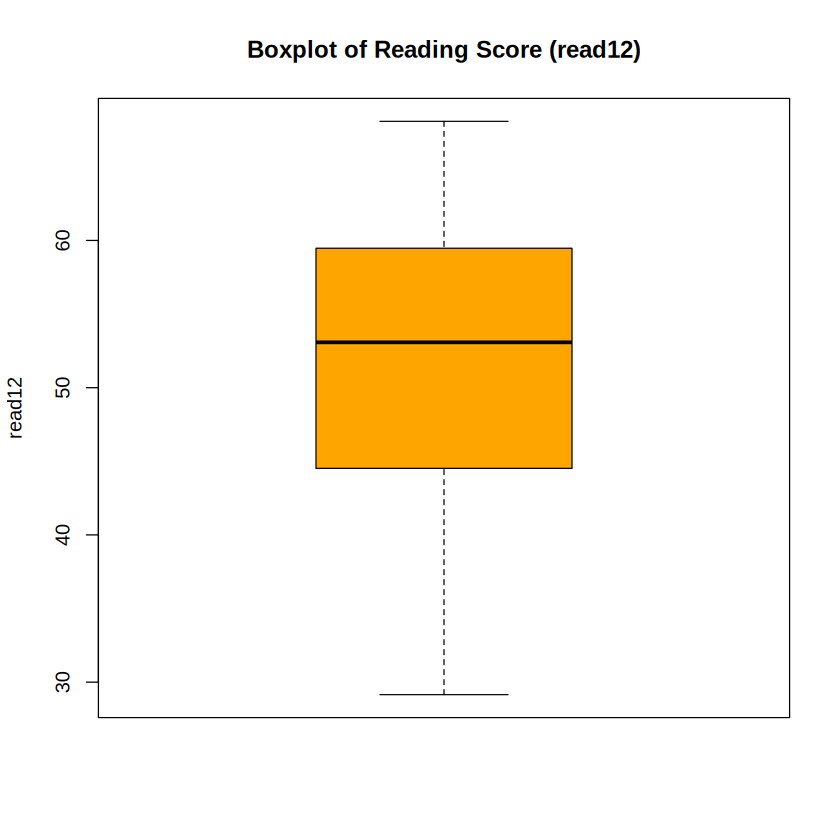

In [5]:
bins <- cut(df$read12, breaks = seq(20, 70, by = 5))
bin_freq <- table(bins)
print(bin_freq)

hist(df$read12, breaks = seq(20, 70, by = 5), col = "lightgreen",
     main = "Histogram of Reading Score (read12)", xlab = "read12")

boxplot(df$read12, main = "Boxplot of Reading Score (read12)",
        ylab = "read12", col = "orange")


In [6]:
cont_table <- table(df$female, df$cathhs)
dimnames(cont_table) <- list(female = c("Male","Female"), cathhs = c("No","Yes"))
print(cont_table)

row_pct <- prop.table(cont_table, margin = 1) * 100
col_pct <- prop.table(cont_table, margin = 2) * 100
print(round(row_pct, 2))
print(round(col_pct, 2))

        cathhs
female     No  Yes
  Male   3341  245
  Female 3637  207
        cathhs
female      No   Yes
  Male   93.17  6.83
  Female 94.61  5.39
        cathhs
female      No   Yes
  Male   47.88 54.20
  Female 52.12 45.80


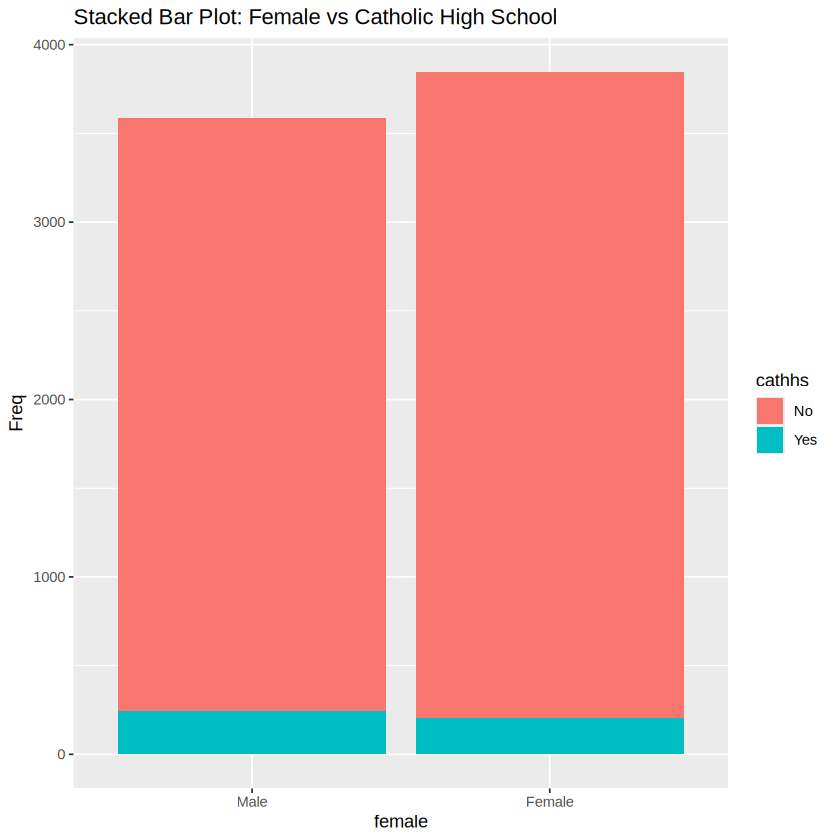

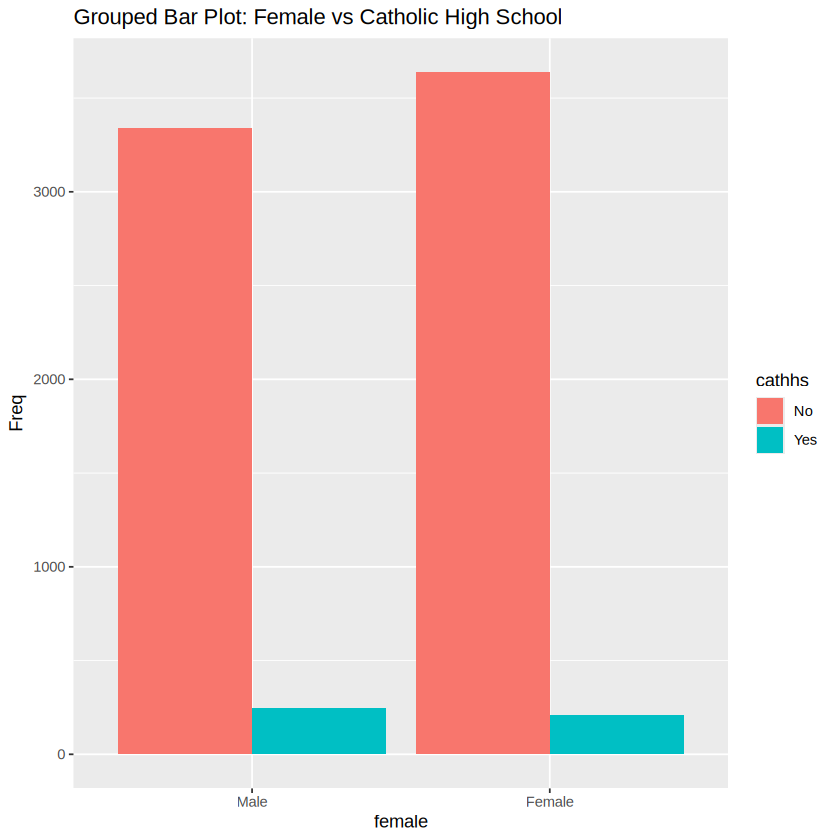

In [7]:
cont_df <- as.data.frame(cont_table)
colnames(cont_df) <- c("female","cathhs","Freq")

ggplot(cont_df, aes(x = female, y = Freq, fill = cathhs)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(title = "Stacked Bar Plot: Female vs Catholic High School")

ggplot(cont_df, aes(x = female, y = Freq, fill = cathhs)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Grouped Bar Plot: Female vs Catholic High School")

In [8]:
agg_stats <- aggregate(math12 ~ cathhs, data = df,
                        FUN = function(x) c(mean = mean(x), median = median(x), sd = sd(x)))
print(agg_stats)

  cathhs math12.mean math12.median math12.sd
1      0   51.922991     52.255000  9.480663
2      1   55.385376     56.035000  8.489789


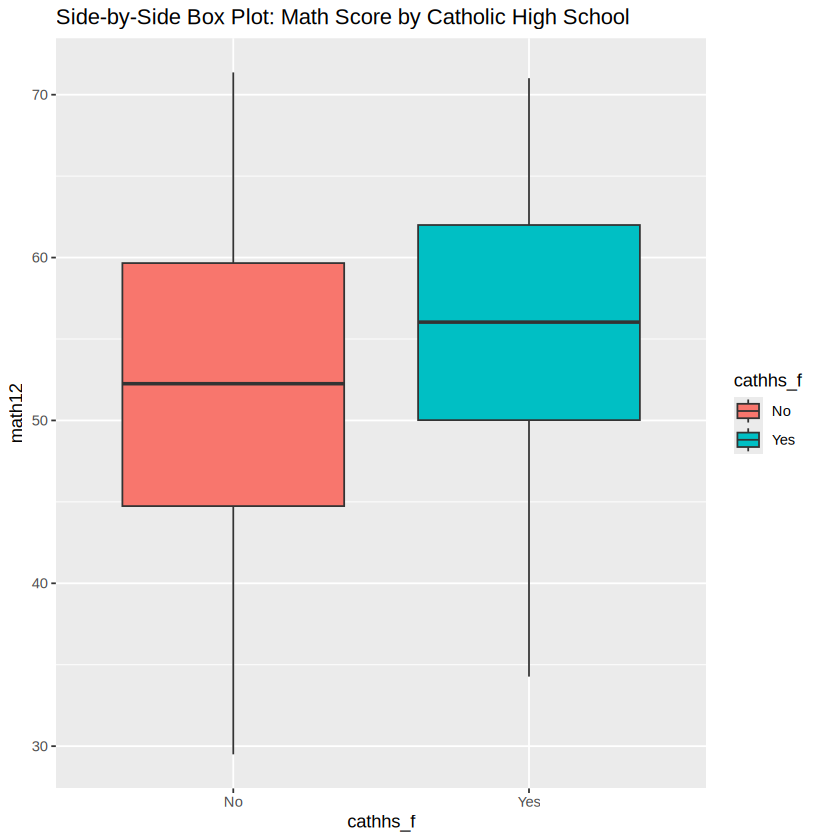

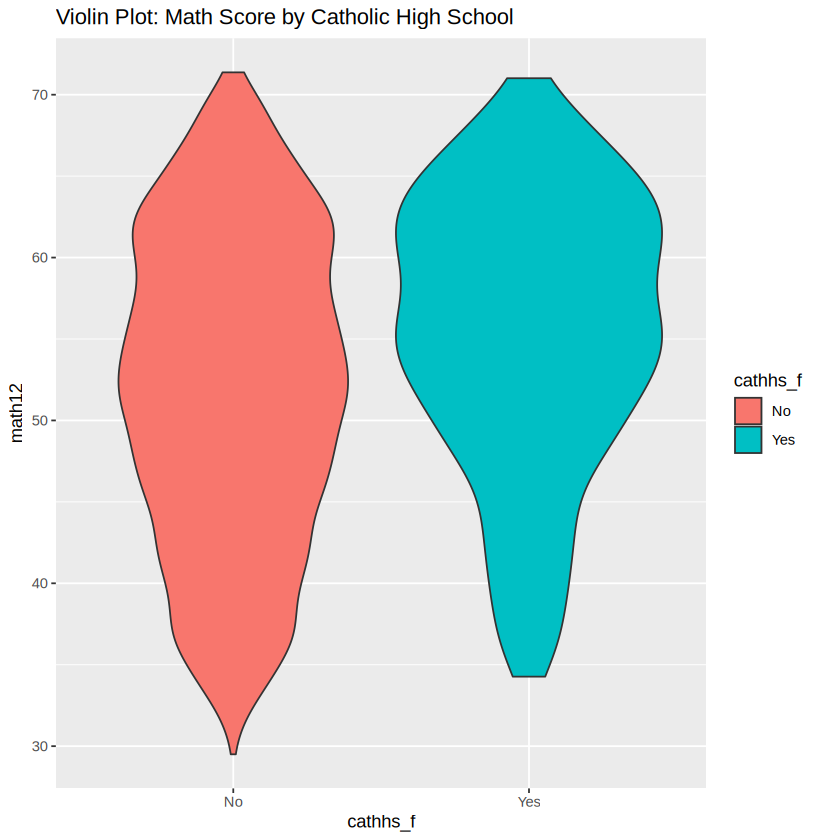

In [9]:
df$cathhs_f <- factor(df$cathhs, labels = c("No","Yes"))

ggplot(df, aes(x = cathhs_f, y = math12, fill = cathhs_f)) +
  geom_boxplot() +
  labs(title = "Side-by-Side Box Plot: Math Score by Catholic High School")

ggplot(df, aes(x = cathhs_f, y = math12, fill = cathhs_f)) +
  geom_violin() +
  labs(title = "Violin Plot: Math Score by Catholic High School")


[1] 0.7104134
[1] 0.7096083


`geom_smooth()` using formula = 'y ~ x'


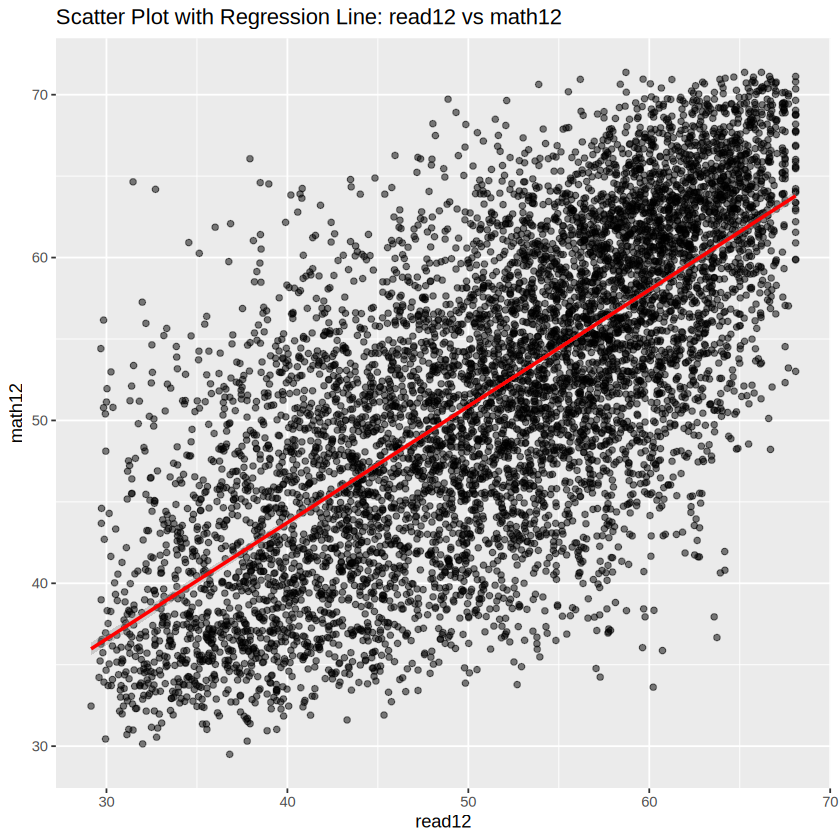

In [10]:
pearson_corr <- cor(df$read12, df$math12, method = "pearson", use = "complete.obs")
spearman_corr <- cor(df$read12, df$math12, method = "spearman", use = "complete.obs")
print(pearson_corr)
print(spearman_corr)

ggplot(df, aes(x = read12, y = math12)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Scatter Plot with Regression Line: read12 vs math12")


# A tibble: 4 × 4
  female_f cathhs_f  Mean    SD
  <fct>    <fct>    <dbl> <dbl>
1 Male     No        52.7  9.60
2 Male     Yes       56.3  8.44
3 Female   No        51.2  9.31
4 Female   Yes       54.3  8.43


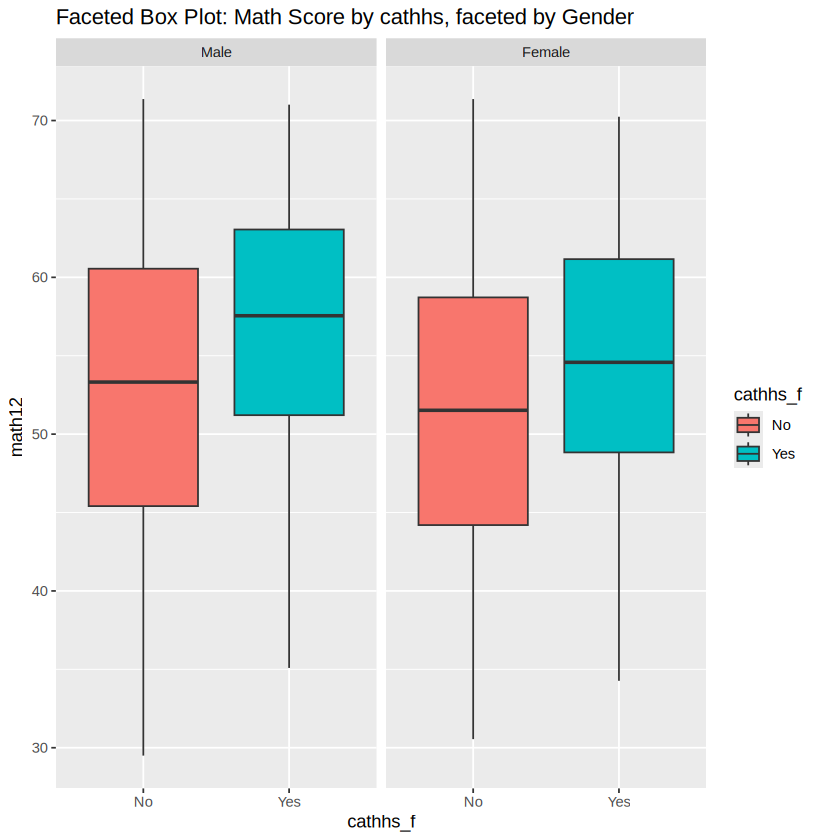

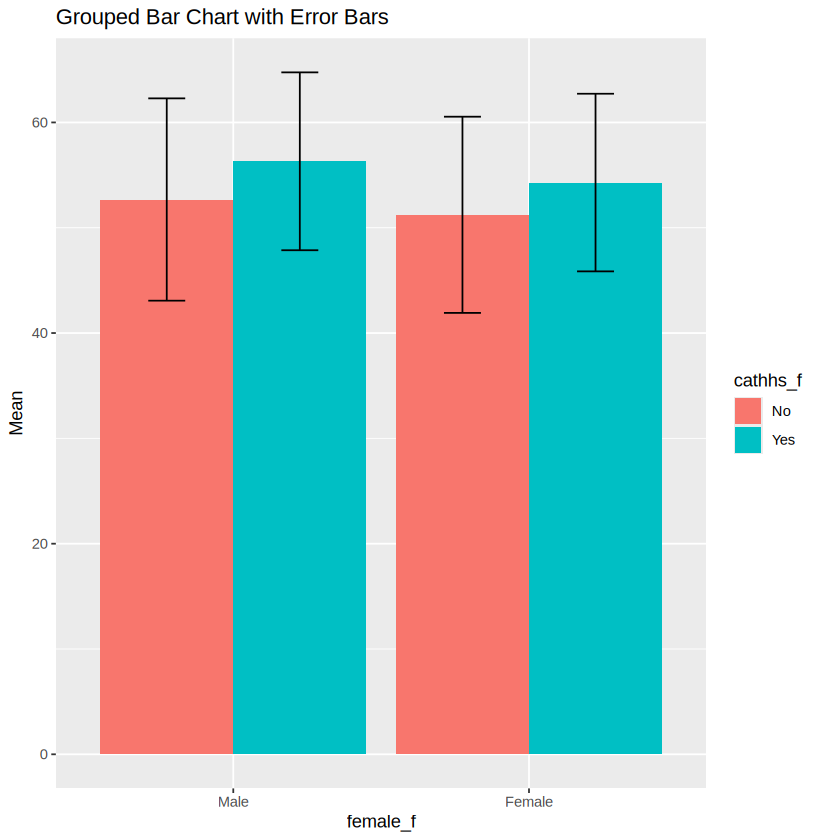

In [11]:
df$female_f <- factor(df$female, labels = c("Male","Female"))

summary_11 <- df %>%
  group_by(female_f, cathhs_f) %>%
  summarise(Mean = mean(math12, na.rm = TRUE),
            SD = sd(math12, na.rm = TRUE),
            .groups = "drop")
print(summary_11)

ggplot(df, aes(x = cathhs_f, y = math12, fill = cathhs_f)) +
  geom_boxplot() +
  facet_wrap(~ female_f) +
  labs(title = "Faceted Box Plot: Math Score by cathhs, faceted by Gender")

ggplot(summary_11, aes(x = female_f, y = Mean, fill = cathhs_f)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  geom_errorbar(aes(ymin = Mean - SD, ymax = Mean + SD),
                position = position_dodge(0.9), width = 0.25) +
  labs(title = "Grouped Bar Chart with Error Bars")

# A tibble: 2 × 2
  cathhs_f correlation
  <fct>          <dbl>
1 No             0.714
2 Yes            0.616


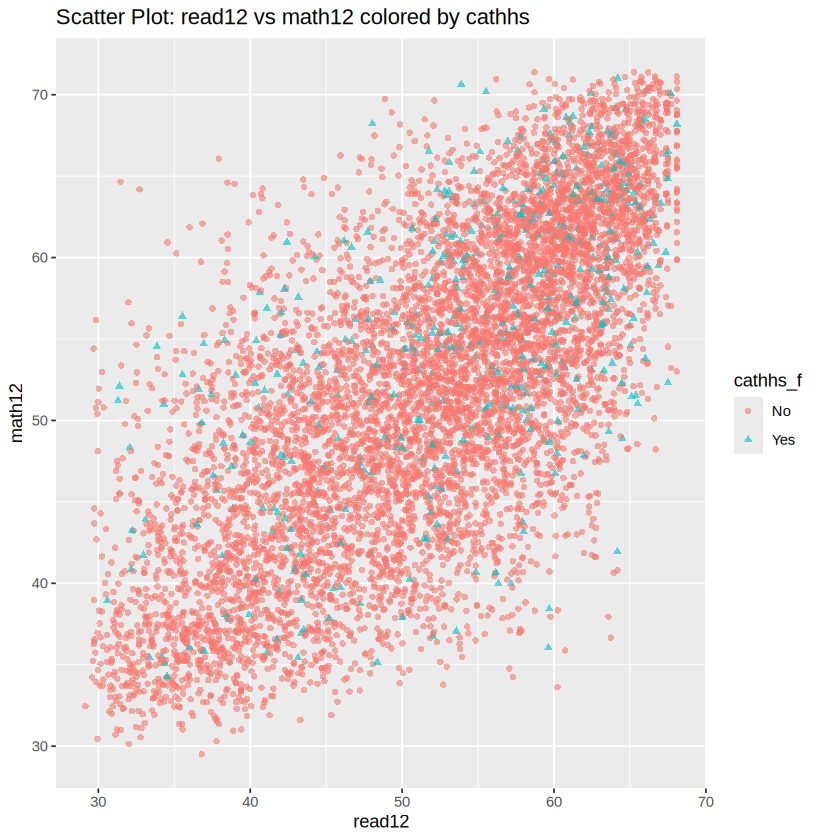

In [12]:
ggplot(df, aes(x = read12, y = math12, color = cathhs_f, shape = cathhs_f)) +
  geom_point(alpha = 0.6) +
  labs(title = "Scatter Plot: read12 vs math12 colored by cathhs")

corr_by_group <- df %>%
  group_by(cathhs_f) %>%
  summarise(correlation = cor(read12, math12, use = "complete.obs"))
print(corr_by_group)


         read12 math12 motheduc fatheduc lfaminc
read12    1.000  0.710    0.285    0.317   0.259
math12    0.710  1.000    0.342    0.375   0.316
motheduc  0.285  0.342    1.000    0.583   0.405
fatheduc  0.317  0.375    0.583    1.000   0.446
lfaminc   0.259  0.316    0.405    0.446   1.000


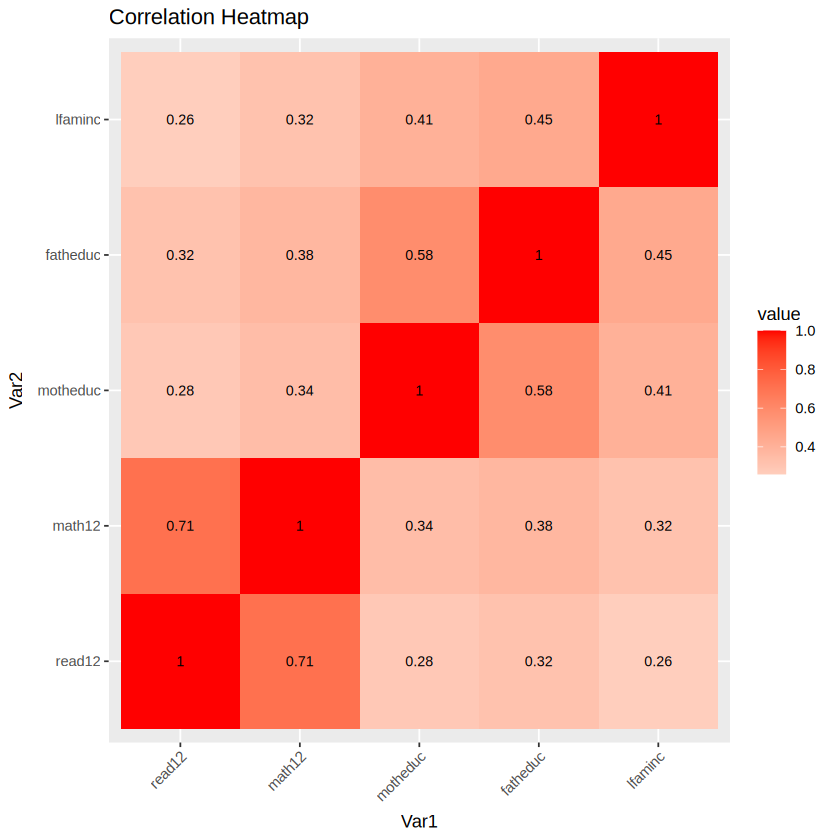

In [13]:
num_vars <- df %>% select(read12, math12, motheduc, fatheduc, lfaminc)
corr_matrix <- cor(num_vars, use = "complete.obs")
print(round(corr_matrix, 3))

melted_corr <- melt(corr_matrix)
ggplot(melted_corr, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2)), size = 3) +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  labs(title = "Correlation Heatmap") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

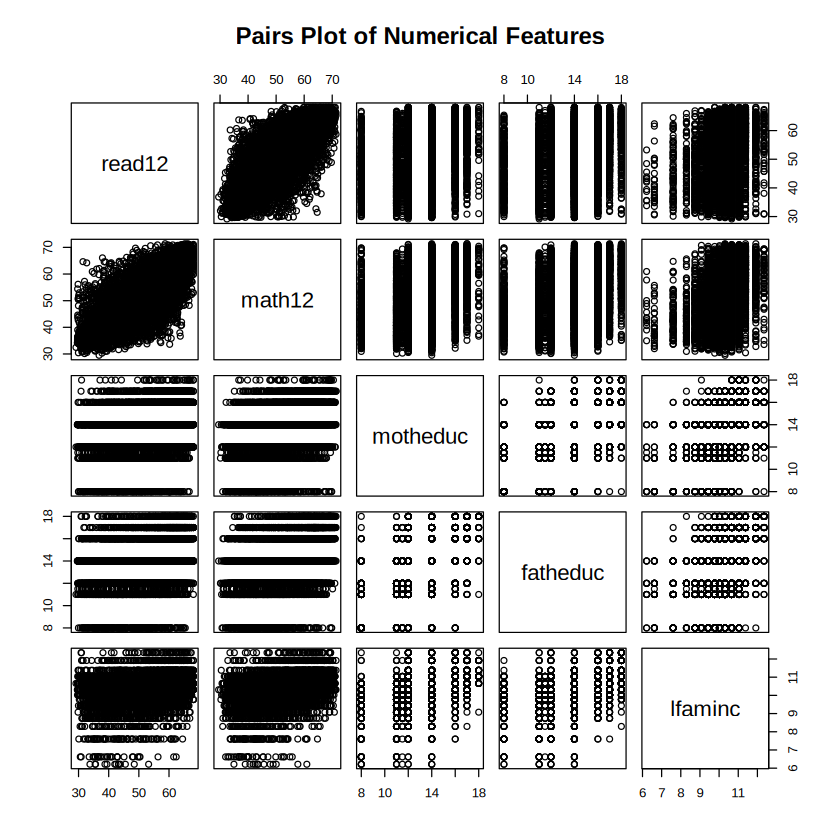

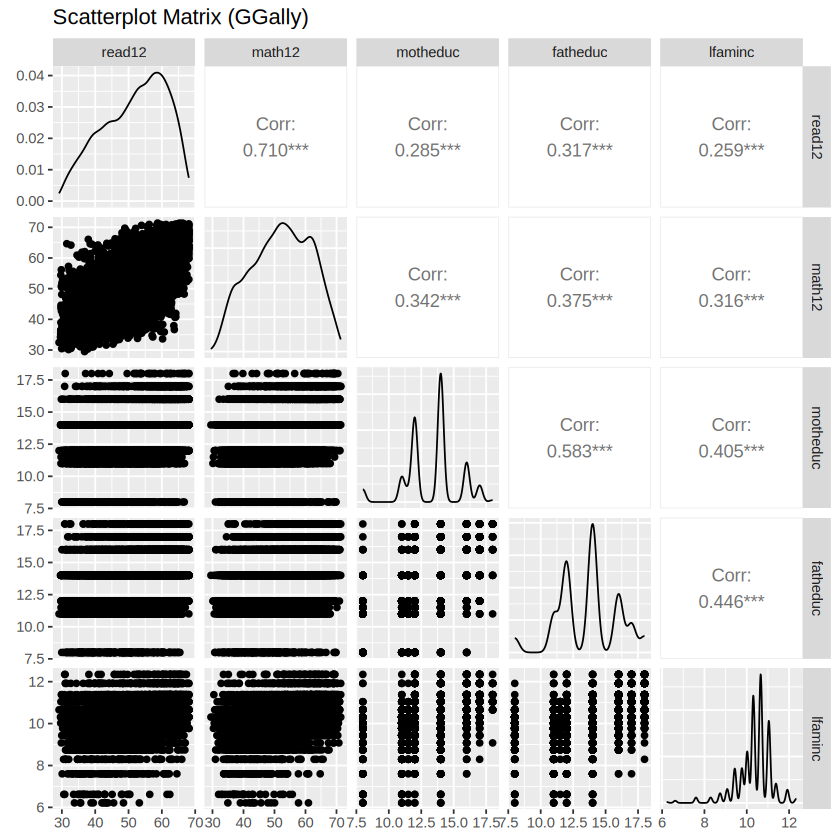

In [14]:
pairs(num_vars, main = "Pairs Plot of Numerical Features")

ggpairs(num_vars, title = "Scatterplot Matrix (GGally)")